In [1]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from pathlib import Path
from main_funcs import *
import nevergrad as ng
import numpy as np
import datetime
import pickle
import sigfig
import os

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times"],
    'font.size'           : 14,            # body text size (most journals use 10 pt)
    'axes.titlesize'      : 14,
    'axes.labelsize'      : 14,            # axis-label size matches body text
    'xtick.labelsize'     : 14,             # tick labels one point smaller
    'ytick.labelsize'     : 14,
    'legend.fontsize'     : 14,             # legend text one point smaller
    'axes.prop_cycle'     : mpl.cycler('color', [   # Okabe–Ito colorblind-safe palette
        '#0072B2', '#D55E00', '#009E73',
        '#E69F00', '#CC79A7', '#56B4E9',
    ]),
    'lines.linewidth'     : 1.5,           # slightly thicker for print clarity
    'axes.linewidth'      : 0.8,           # thinner axis frame
    'xtick.direction'     : 'in',          # inward ticks — journal standard
    'ytick.direction'     : 'in',
    'xtick.minor.visible' : True,          # show minor ticks
    'ytick.minor.visible' : True,
    'xtick.major.size'    : 4,             # longer than the 3.5 default
    'ytick.major.size'    : 4,
    'xtick.minor.size'    : 2,             # half of major — proportional
    'ytick.minor.size'    : 2,
    'xtick.major.width'   : 0.8,           # match axes.linewidth
    'ytick.major.width'   : 0.8,
    'xtick.minor.width'   : 0.6,           # thinner for visual hierarchy
    'ytick.minor.width'   : 0.6,
    'lines.markersize'    : 4,             # smaller markers for print scale
    'errorbar.capsize'    : 3,             # visible end-caps (default is 0)
    'axes.xmargin'        : 0.02,          # hug the data (default is 0.05)
    'axes.ymargin'        : 0.02,
    'legend.frameon'      : False,         # no legend box
    'savefig.bbox'        : 'tight',       # tight bounding box by default
    'savefig.dpi'         : 300,           # publication-quality resolution
    **(                                    # LaTeX if installed, else fallback
        {'text.usetex'        : True,              # real LaTeX for all text
         'text.latex.preamble': r'\usepackage{amsmath} \usepackage{amssymb}',
         'pgf.texsystem'     : 'pdflatex',         # consistent PGF export
         'pgf.rcfonts'       : False}               # let LaTeX control fonts
        if __import__('shutil').which('latex') else
        {'text.usetex'        : False,             # no TeX install found
         'mathtext.fontset'  : 'cm'}               # Computer Modern via mathtext
    ),
})

In [118]:
base_dirs = {
    "Without": Path("data/Without EDM"),
    "With": Path("data/With EDM"),
    "Without New": Path("data/Without EDM NEW"),
    "With New": Path("data/With EDM NEW")
}

data_all = load_array_data(base_dirs)

full_w = np.ones(shape = (500,500))
# full_w = np.load("analytic_weights_cma_lead.npz",allow_pickle=True)["weight"].T
wt = 2*np.pi*np.arange(0,29,1)/29

In [119]:
def delta_fit(x,A,B):
    return A*np.sin(x) / (1 + B*np.cos(x))

def delta_for_alpha(data_all=data_all, alpha=1.0, wt=wt, w=full_w):
    X = data_all["With New"][0]["X"][0, :]

    all_means = []
    all_sems = []

    A_vals = []
    A_errs = []
    B_vals = []
    B_errs = []

    fitted_lams = []

    for i_lambda, lam in enumerate(X):
        run_means = []
        run_sems = []

        for run_id, grids in data_all["With New"].items():
            withEDM = grids["Z"][:, i_lambda]
            withoutEDM = data_all["Without New"][run_id]["Z"][:,i_lambda]

            Z = alpha*(withEDM - withoutEDM) + withoutEDM
            Y_vals = grids["Y"][:, 0]
            w = full_w[:, i_lambda]

            mean, sig, sem = calculate_metrics_array(Z, Y_vals, 1e6, w=w)

            run_means.append(mean)
            run_sems.append(sem)

        run_means = np.asarray(run_means)
        run_sems  = np.asarray(run_sems)

        all_means.append(run_means)
        all_sems.append(run_sems)

        good = np.isfinite(run_means) & np.isfinite(run_sems) & (run_sems > 0)
        if good.sum() < 3:
            continue

        popt, pcov = curve_fit(
            delta_fit,
            wt[good],
            run_means[good],
            sigma=run_sems[good],
            absolute_sigma=True
        )

        fitted_lams.append(lam)
        A_vals.append(popt[0])
        A_errs.append(np.sqrt(pcov[0,0]))
        B_vals.append(popt[1])
        B_errs.append(np.sqrt(pcov[1,1]))
        
        # for i, param in zip(range(len(popt)), ["A","B"]):
        #     print(f"{param}: {popt[i]}+-{np.diag(np.sqrt(pcov))[i,i]}")

    fitted_lams = np.asarray(fitted_lams)
    A_vals = np.asarray(A_vals)
    A_errs = np.asarray(A_errs)
    B_vals = np.asarray(B_vals)
    B_errs = np.asarray(B_errs)

    return (fitted_lams, A_vals, A_errs, B_vals, B_errs, all_means, all_sems)

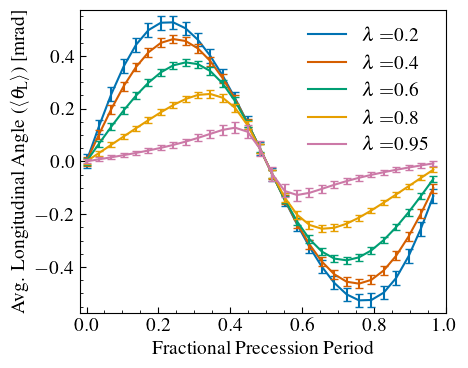

In [121]:
fitted_lams, A_vals, A_errs, B_vals, B_errs, all_means, all_sems = delta_for_alpha(data_all)

chosen_lambdas = np.array([0.2,0.4,0.6,0.8,0.95])

chosen_colors = [   # Okabe–Ito colorblind-safe palette
        '#0072B2', '#D55E00', '#009E73',
        '#E69F00', '#CC79A7', '#56B4E9',
    ]

mm = 1 / 25.4

fig, ax = plt.subplots(
figsize=(120 * mm, 100 * mm)
)

for color, lam in zip(chosen_colors,chosen_lambdas):
    idx = np.argmin(np.abs(fitted_lams - lam))
    lam_plot = fitted_lams[idx]

    ax.plot(wt/(2*np.pi), delta_fit(wt, A_vals[idx], B_vals[idx]), label=fr"$\lambda=${lam:.3g}",color=color)
    ax.errorbar(wt/(2*np.pi), all_means[idx], yerr=all_sems[idx], linestyle='',color=color)
ax.set_xlabel(r"Fractional Precession Period")
ax.set_ylabel(r"Avg. Longitudinal Angle ($\langle\theta_\mathrm{L}\rangle$) [mrad]")

ticks = np.arange(0.0,1.2,0.2)

ax.set_xticks(ticks)

plt.legend()
plt.savefig("final diss plots/time_evolution.png")
plt.show()

In [76]:
lambda_tot = fitted_lams

def weighted_model(x, C, b):
    return C*x+b

def unweighted_model(x, C):
    return C*((x-1)*(2*x+1) / (4*x**2 - 5*x - 5))

def extract_delta(model, lambda_tot, A_vals, A_errs):
    popt, pcov = curve_fit(model, lambda_tot, A_vals, sigma=A_errs)

    C = popt[0]
    C_err = np.sqrt(pcov[0,0])

    gamma = 29.303431969091314
    delta = C*gamma*1e-3
    delta_err = C_err*gamma*1e-3

    return (popt, pcov, delta, delta_err)

delta = (-0.05004 ± 0.00008)


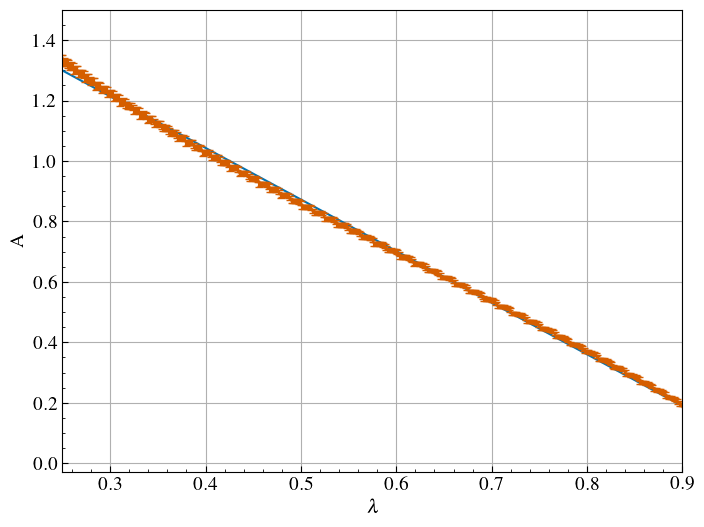

chi^2 = 2120.628
ndof  = 498
chi^2/ndof = 4.258


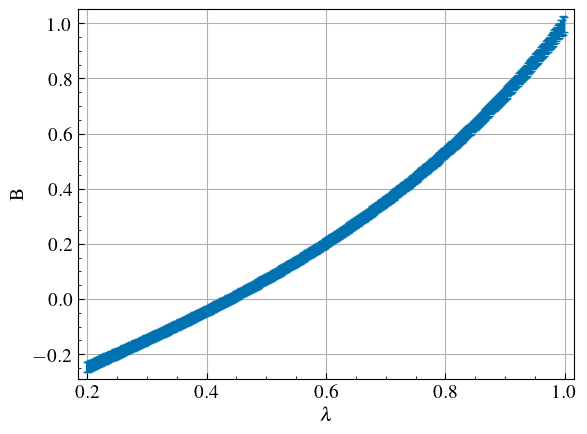

In [77]:
popt, pcov, delta, delta_err = extract_delta(weighted_model, lambda_tot, A_vals, A_errs)
print(f"delta = ({sigfig.round(delta, uncertainty=delta_err)})")

plt.figure(figsize=(8,6))
plt.plot(lambda_tot, weighted_model(lambda_tot, *popt))
plt.errorbar(lambda_tot,A_vals,yerr=A_errs)
plt.xlabel(r"$\lambda$")
plt.ylabel("A")
plt.grid()
plt.xlim([0.25,0.9])
plt.show()

# predicted values
A_model = weighted_model(lambda_tot, *popt)

# chi^2
chi2 = np.sum(((A_vals - A_model) / A_errs)**2)

# degrees of freedom (N data points - N fitted params)
ndof = len(A_vals) - 1

# reduced chi^2
chi2_red = chi2 / ndof

print(f"chi^2 = {chi2:.3f}")
print(f"ndof  = {ndof}")
print(f"chi^2/ndof = {chi2_red:.3f}")

plt.clf()
plt.errorbar(lambda_tot,B_vals,yerr=B_errs)
plt.xlabel(r"$\lambda$")
plt.ylabel("B")
plt.grid()
plt.show()

alpha=-2: 100.1 ± 0.2
3.4150684218391403 0.0053052124827585485
alpha=-1: 50.04 ± 0.08
1.707564861601168 0.0026525074755164185
alpha=-0.5: 25.02 ± 0.04
0.85378629909885 0.0013262418563397874
alpha=0.5: -25.02 ± 0.04
-0.8537862951682662 0.001326241845072211
alpha=0.75: -37.53 ± 0.06
-1.280677055434197 0.0019893704690231283
alpha=1.0: -50.04 ± 0.08
-1.707564853324971 0.0026525074379683935
alpha=2.0: -100.1 ± 0.2
-3.415068407953242 0.005305212489282479
alpha=5.0: -250.2 ± 0.4
-8.536576144445462 0.01326654199904645
alpha=10.0: -500.1 ± 0.8
-17.06464220426569 0.02655986277092168


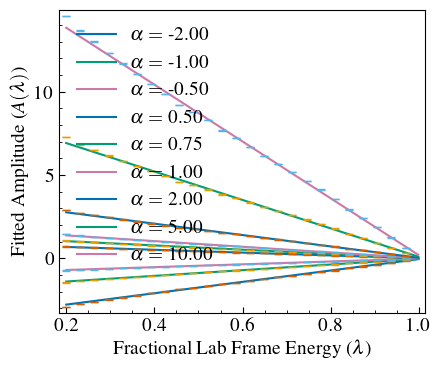

In [114]:
alphas = [-2,-1,-0.5,0.5,0.75,1.0,2.0,5.0,10.0]
deltas = np.array(alphas)*80

mm = 1 / 25.4

fig, ax = plt.subplots(
figsize=(120 * mm, 100 * mm)
)
gradients = []
gradients_err = []

step = 20

for alpha, delta in zip(alphas, deltas):
    fitted_lams, A_vals, A_errs, B_vals, B_errs, all_means, all_sems = delta_for_alpha(data_all, alpha=alpha)

    popt, pcov, grad, grad_err = extract_delta(weighted_model, lambda_tot, A_vals, A_errs)

    C = popt[0]
    C_err = np.sqrt(pcov[0,0])

    gamma = 29.303431969091314
    delta = C * gamma
    delta_err = C_err * gamma

    print(f"alpha={alpha}: {sigfig.round(delta, uncertainty=delta_err)}")  
    print(popt[0], pcov[0,0]**0.5)  

    gradients.append(popt[0])
    gradients_err.append(pcov[0,0]**0.5)

    # smooth fit (keep full)
    ax.plot(lambda_tot, weighted_model(lambda_tot, *popt), label=fr"$\alpha=$ {alpha:.2f}")

    # downsampled data
    ax.errorbar(lambda_tot[::step],
                A_vals[::step],
                yerr=A_errs[::step],
                linestyle='',)
                #color=color)

ax.set_xlabel(r"Fractional Lab Frame Energy ($\lambda$)")
ax.set_ylabel(r"Fitted Amplitude ($A(\lambda)$)")
plt.legend()
# plt.savefig("final diss plots/weighted ampltiude.png")
plt.show()

[np.float64(0.0053052124827585485), np.float64(0.0026525074755164185), np.float64(0.0013262418563397874), np.float64(0.001326241845072211), np.float64(0.0019893704690231283), np.float64(0.0026525074379683935), np.float64(0.005305212489282479), np.float64(0.01326654199904645), np.float64(0.02655986277092168)]


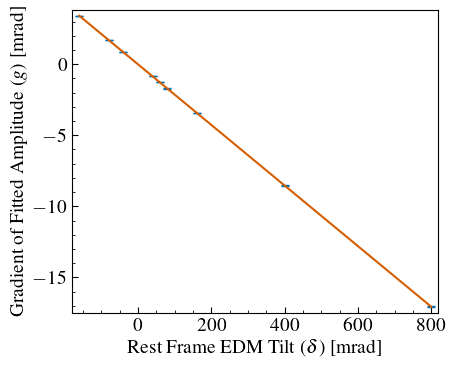

m = -0.021334 ± 0.000002
c = -0.0002 ± 0.0007


In [128]:
mm = 1 / 25.4

fig, ax = plt.subplots(figsize=(120 * mm, 100 * mm))

def grad_model(delta, m, c):
    return m * delta + c

popt, pcov = curve_fit(grad_model, deltas, gradients)

m, c = popt
m_err, c_err = np.sqrt(np.diag(pcov))

# plot data
ax.errorbar(deltas, gradients,yerr=gradients_err, linestyle='')
print(gradients_err)
# plot fitted line
delta_fitted = np.linspace(min(deltas), max(deltas), 200)
ax.plot(delta_fitted, grad_model(delta_fitted, *popt))

ax.set_xlabel(r"Rest Frame EDM Tilt ($\delta$) [mrad]")
ax.set_ylabel(r"Gradient of Fitted Amplitude ($g$) [mrad]")
plt.savefig("final diss plots/gradient fit.png")
plt.show()

print(f"m = {sigfig.round(m, uncertainty=m_err)}")
print(f"c = {sigfig.round(c, uncertainty=c_err)}")

In [116]:
# chi^2
print((gradients - grad_model(deltas, *popt)) / gradients_err)
chi2 = np.sum(((gradients - grad_model(deltas, *popt)) / gradients_err)**2)

# degrees of freedom (N data points - N fitted params)
ndof = len(gradients) - 1

# reduced chi^2
chi2_red = chi2 / ndof
chi2_red

[ 0.3514403   0.39556183  0.46358886 -0.20315888 -0.2453624  -0.26534637
 -0.28633393 -0.22325504  0.09087943]


np.float64(0.10085850210447644)

In [127]:
g_meas = -1.707564853324971
g_err = 0.0026525074379683935

m_err = np.sqrt(pcov[0,0])
c_err = np.sqrt(pcov[1,1])
cov_mc = pcov[0,1]

delta = (g_meas - c) / m

print((g_err / m)**2 ,
    (c_err / m)**2 ,
    (delta * m_err / m)**2 ,
    2 * delta * cov_mc / m**2)

delta_err = np.sqrt(
    (g_err / m)**2 +
    (c_err / m)**2 +
    (delta * m_err / m)**2 +
    2 * delta * cov_mc / m**2
)

print(sigfig.round(delta, uncertainty=delta_err))

0.015459119677509353 0.0009914041479529819 6.561894521148888e-05 -0.00022951481027547416
80.0 ± 0.1
